In [ ]:
import pandas as pd
df=pd.read_csv('C:\\Users\\Hp\\OneDrive\\Documents\\IEEE\\Task 2(Pandas)\\titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [55]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsChild,IsAlone
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.000000,891,891.000000,891,891.000000,891,891.000000
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,3,NaN,2,NaN
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,S,NaN,False,NaN
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,646,NaN,808,NaN
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699120,0.523008,0.381594,NaN,32.204208,NaN,0.904602,NaN,0.602694
std,257.353842,0.486592,0.836071,NaN,NaN,13.002015,1.102743,0.806057,NaN,49.693432,NaN,1.613459,NaN,0.489615
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.000000,NaN,7.910400,NaN,0.000000,NaN,0.000000
50%,446.000000,0.000000,3.000000,NaN,NaN,29.699118,0.000000,0.000000,NaN,14.454200,NaN,0.000000,NaN,1.000000
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.000000,NaN,1.000000,NaN,1.000000


In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [28]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["Cabin"], errors="ignore")

df = df.astype({
    "Survived": "int8",
    "PassengerId": "int16",
    "Pclass": "int8",
    "SibSp": "int8",
    "Parch": "int8",
    "Age": "float32",
    "Fare": "float32"
})

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int16  
 1   Survived     891 non-null    int8   
 2   Pclass       891 non-null    int8   
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float32
 6   SibSp        891 non-null    int8   
 7   Parch        891 non-null    int8   
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float32
 10  Embarked     891 non-null    str    
dtypes: float32(2), int16(1), int8(4), str(4)
memory usage: 40.2 KB


In [29]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["FamilySize"] = df["SibSp"] + df["Parch"]
df["IsAlone"] = (df["FamilySize"] == 0).astype(int)
df["IsChild"] = (df["Age"] < 16).astype(int)  

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,IsChild
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.250000,Southampton,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.283302,Cherbourg,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925000,Southampton,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.099998,Southampton,1,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.050000,Southampton,0,1,0


In [87]:

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Embarked"] = df["Embarked"].map({
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton",
})



Survival Count:


,Count
Did Not Survive,549
Survived,342


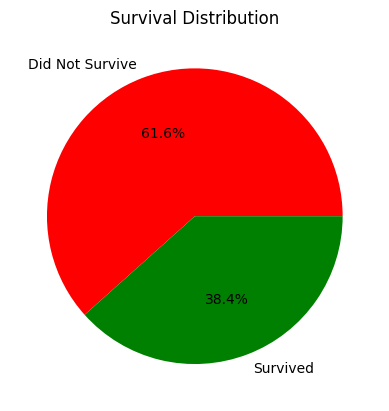

In [7]:
pivot_survival = df.pivot_table(values="PassengerId", index="Survived", aggfunc="count")
pivot_survival.index = ["Did Not Survive", "Survived"]
pivot_survival.columns = ["Count"]

print("Survival Count:")
display(pivot_survival.style.format("{}"))

pivot_survival["Count"].plot(kind="pie", autopct="%1.1f%%",
                              colors=["red", "green"])
plt.title("Survival Distribution")
plt.ylabel("")
plt.show()

Survival Rate by Gender:


,Survived
Female,74.2%
Male,18.9%


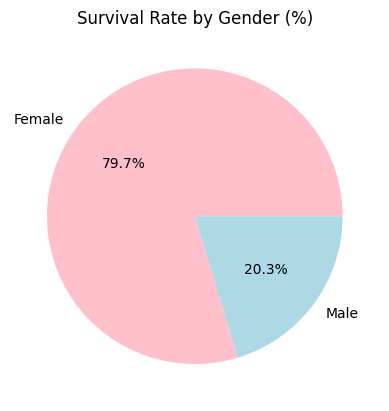

In [127]:
pivot_gender = df.pivot_table(values="Survived", index="Sex", aggfunc="mean") * 100
pivot_gender = pivot_gender.round(1)
pivot_gender.index = ["Female", "Male"]

print("Survival Rate by Gender:")
display(pivot_gender.style.format("{:.1f}%"))


pivot_gender["Survived"].plot(kind="pie",autopct="%1.1f%%",colors=["pink", "lightblue"])

plt.title("Survival Rate by Gender (%)")
plt.ylabel("")
plt.show()

,First Class,Second Class,Third Class
Sex,,,
female,96.8%,92.1%,50.0%
male,36.9%,15.7%,13.5%


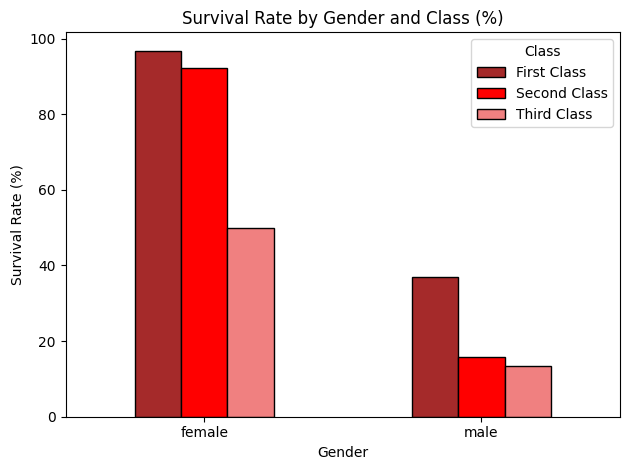

In [121]:
pivot1 = df.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean") * 100
pivot1 = pivot1.round(1)
pivot1.columns = ["First Class", "Second Class", "Third Class"]

display(pivot1.style.format("{:.1f}%"))

pivot1.plot(kind="bar", color=["brown", "red", "lightcoral"], edgecolor="black")

plt.title("Survival Rate by Gender and Class (%)")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

Average Fare by Port and Class:


,First Class,Second Class,Third Class
Embarked,,,
Cherbourg,$104.7,$25.4,$11.2
Queenstown,$90.0,$12.4,$11.2
Southampton,$70.5,$20.3,$14.6


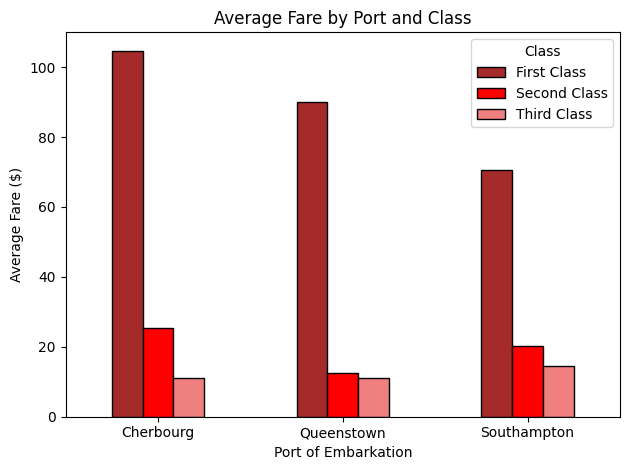

In [122]:
pivot_fare = df.pivot_table(values="Fare", index="Embarked", columns="Pclass", aggfunc="mean")
pivot_fare = pivot_fare.round(1)
pivot_fare.columns = ["First Class", "Second Class", "Third Class"]
print("Average Fare by Port and Class:")

display(pivot_fare.style.format("${:.1f}"))


pivot_fare.plot(kind="bar", color=["brown", "red", "lightcoral"], edgecolor="black")

plt.title("Average Fare by Port and Class")
plt.xlabel("Port of Embarkation")
plt.ylabel("Average Fare ($)")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()



Survival Rate by Family Size:


,Survival Rate (%)
FamilySize,
0,30.4%
1,55.3%
2,57.8%
3,72.4%
4,20.0%
5,13.6%
6,33.3%
7,0.0%
10,0.0%


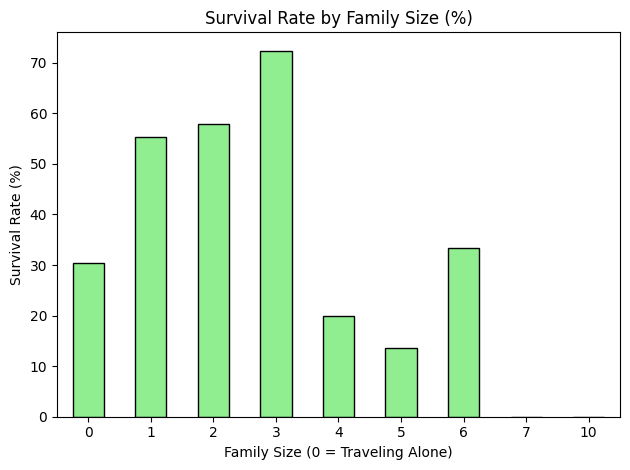

In [139]:
pivot_family = df.pivot_table(values="Survived", index="FamilySize", aggfunc="mean") * 100
pivot_family = pivot_family.round(1)
pivot_family.columns = ["Survival Rate (%)"]

print("Survival Rate by Family Size:")
display(pivot_family.style.format("{:.1f}%"))

pivot_family.plot(kind="bar", color="lightgreen", edgecolor="black", legend=False)
plt.title("Survival Rate by Family Size (%)")
plt.xlabel("Family Size (0 = Traveling Alone)")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Passenger Count by Age Group:


,Count
AgeGroup,
0-15,83
16-30,503
31-45,202
46+,103


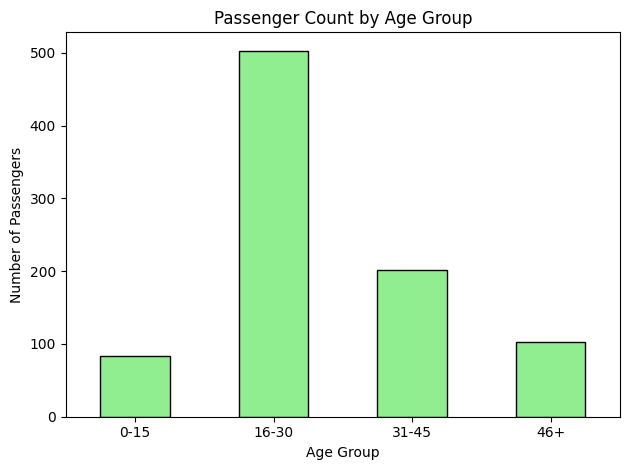

In [144]:
df["AgeGroup"] = df["Age"].apply(lambda x:
    "0-15"  if x <= 15 else
    "16-30" if x <= 30 else
    "31-45" if x <= 45 else
    "46+"
)

pivot_age = df.pivot_table(values="PassengerId", index="AgeGroup", aggfunc="count")
pivot_age.columns = ["Count"]

print("Passenger Count by Age Group:")
display(pivot_age.style.format("{}"))

pivot_age["Count"].plot(kind="bar", color="lightgreen", edgecolor="black", legend=False)
plt.title("Passenger Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Survival Rate: Alone vs With Family


,Survival Rate (%)
With Family,50.6%
Alone,30.4%


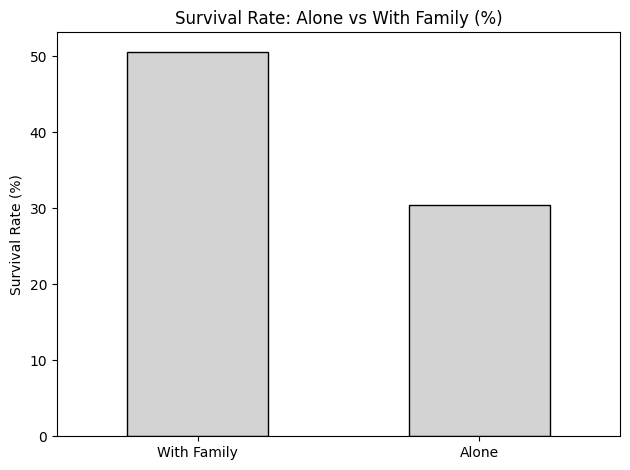

In [13]:
pivot_alone = df.pivot_table(values="Survived", index="IsAlone", aggfunc="mean") * 100
pivot_alone = pivot_alone.round(1)
pivot_alone.index   = ["With Family", "Alone"]
pivot_alone.columns = ["Survival Rate (%)"]

print("Survival Rate: Alone vs With Family")
display(pivot_alone.style.format("{:.1f}%"))

pivot_alone.plot(kind="bar", color=["lightgray", "red"], edgecolor="black", legend=False)
plt.title("Survival Rate: Alone vs With Family (%)")
plt.xlabel("")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Survival Rate: Adults vs Children


,Survival Rate (%)
Adult,36.3%
Child,59.0%


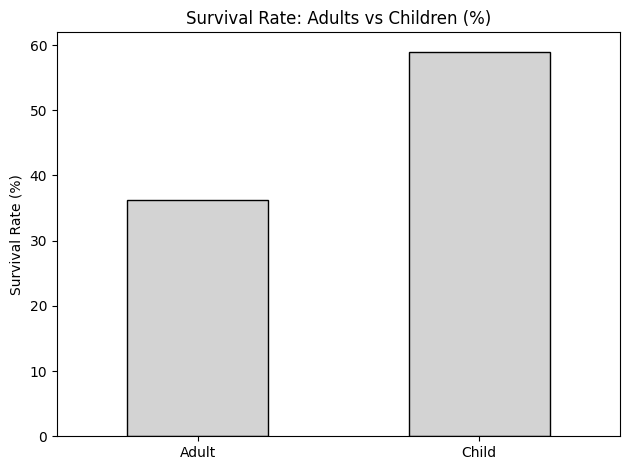

In [16]:
pivot_child = df.pivot_table(values="Survived", index="IsChild", aggfunc="mean") * 100
pivot_child = pivot_child.round(1)
pivot_child.index   = ["Adult", "Child"]
pivot_child.columns = ["Survival Rate (%)"]

print("Survival Rate: Adults vs Children")
display(pivot_child.style.format("{:.1f}%"))

pivot_child.plot(kind="bar", color=["lightgray", "red"], edgecolor="black", legend=False)
plt.title("Survival Rate: Adults vs Children (%)")
plt.xlabel("")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()